# IoT Traffic Analysis (Experimental Copy)
This notebook is an **experimental copy** to explore **device-type clustering** and **type-label classification** using **flow data**.

What’s new vs the original notebook:
- Build **device-level embeddings** from flow statistics
- Unsupervised **clustering** (KMeans) to see whether devices naturally group by behavior
- A simple way to turn clusters into **type labels**, then train a **flow-based ML classifier** to predict those type labels
- Uses a **group split by device** to avoid leakage (same device appearing in both train and test)

> Note: This stays entirely on flow data (tabular). Packet/DL experiments can be added later once type labels are stable.


In [6]:
# 1) Imports & configuration
import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42

# Adjust this to where your flows CSVs are
FLOW_DATA_GLOB = "unsw-dataset/flows/*.csv"   # or "flows/*.csv" depending on your local folder

# Optional cap to speed up experiments (set to None to use all)
CANTIDAD_META = 500000   # e.g., 200_000

# Columns to drop to reduce identity leakage
DROP_COLS = ['time','srcMac','dstMac','ethType','srcIp','dstIp','ipProto','srcPort','dstPort','flowSeqNum']

# Clustering hyperparams
N_CLUSTERS = 5  # start with 5 for a PoC taxonomy


In [7]:
# 2) Load flow CSVs and add a 'device' label from filename (streaming + optional sampling)
print("\n--- [FLOWS] Loading Data ---")
file_paths = glob.glob(FLOW_DATA_GLOB)
if not file_paths:
    raise FileNotFoundError(f"No CSVs found for pattern: {FLOW_DATA_GLOB}")

# If you set CANTIDAD_META, we sample roughly proportionally per file.
# This keeps memory low and avoids a huge concat before sampling.
total_target = CANTIDAD_META  # None means load all
n_files = len(file_paths)

df_list = []
total_loaded = 0

# If sampling, allocate a per-file quota (rough equal split; good enough for PoC)
per_file_quota = None
if total_target is not None:
    per_file_quota = max(1, total_target // n_files)

for fp in file_paths:
    device_name = os.path.basename(fp).replace("_flows.csv", "")
    usecols = None  # you can set to a list later to reduce memory even more

    if per_file_quota is None:
        df = pd.read_csv(fp, low_memory=False)
    else:
        # Read the file, then sample down (still cheaper than sampling after huge concat)
        df_full = pd.read_csv(fp, low_memory=False)
        df = df_full.sample(n=min(len(df_full), per_file_quota), random_state=RANDOM_STATE)

    df["device"] = device_name
    df_list.append(df)
    total_loaded += len(df)
    print(f"{device_name}: loaded {len(df):,} flows (running total {total_loaded:,})")

df_all = pd.concat(df_list, ignore_index=True)
print(f"\nLoaded {len(df_all):,} flows from {df_all['device'].nunique()} devices.")
display(df_all.head())



--- [FLOWS] Loading Data ---
TPLinkSmartPlug_50c7bf005639: loaded 12,816 flows (running total 12,816)
WithingsSmartScale_0024e41b6f96: loaded 1,530 flows (running total 14,346)
SamsungCamera_00166cab6b88: loaded 18,518 flows (running total 32,864)
NetatmoWelcome_70ee50183443: loaded 18,518 flows (running total 51,382)
BelkinCamera_b4750eece5a9: loaded 18,518 flows (running total 69,900)
AugustDoorBell_e076d03f00ae: loaded 18,518 flows (running total 88,418)
CanaryCamera_7c70bc5d5edc: loaded 6,598 flows (running total 95,016)
PixStarPhotoFrame_e076d033bb85: loaded 15,358 flows (running total 110,374)
WithingsBabyMonitor_0024e41118a8: loaded 11,241 flows (running total 121,615)
BlipCareBPMeter_746a89002e25: loaded 54 flows (running total 121,669)
PhilipsHue_0017882b9a25: loaded 18,518 flows (running total 140,187)
SamsungSmartThings_d052a800675e: loaded 18,518 flows (running total 158,705)
NestDropCam_308cfb2fe4b2: loaded 2,108 flows (running total 160,813)
HelloBarbie_28c2ddffa52d: loa

,time,srcMac,dstMac,ethType,srcIp,dstIp,ipProto,srcPort,dstPort,flowSeqNum,...,flowDuration,srcAvgInterarrivalTime,dstAvgInterarrivalTime,avgInterarrivalTime,srcStdDevInterarrivalTime,dstStdDevInterarrivalTime,stdDevInterarrivalTime,allMatchedProtocols,protocol,device
0,2016-12-02 03:25:13.400998,NaN,NaN,0x0800,192.168.1.228,54.251.165.219,6,46017,50443,5,...,144.0,0.0,0.0,144.0,0.0,0.0,0.0,none,none,TPLinkSmartPlug_50c7bf005639
1,2016-12-04 05:30:16.52329,NaN,NaN,0x0800,192.168.1.228,54.254.250.149,6,45353,50443,9,...,409.0,0.0,265.0,204.5,0.0,0.0,60.5,none,none,TPLinkSmartPlug_50c7bf005639
2,2016-10-01 15:39:11.00023,NaN,NaN,0x0800,192.168.1.227,54.254.250.149,6,51981,50443,18,...,403.0,0.0,259.0,201.5,0.0,0.0,57.5,none,none,TPLinkSmartPlug_50c7bf005639
3,2016-12-02 17:15:02.803261,NaN,NaN,0x0800,192.168.1.228,54.254.250.149,6,47054,50443,13,...,144.0,0.0,0.0,144.0,0.0,0.0,0.0,none,none,TPLinkSmartPlug_50c7bf005639
4,2016-09-30 19:53:57.986998,NaN,NaN,0x0800,192.168.1.227,54.254.250.149,6,36914,50443,7,...,144.0,0.0,0.0,144.0,0.0,0.0,0.0,none,none,TPLinkSmartPlug_50c7bf005639


In [8]:
# 3) Clean: drop identity/leak-prone columns and separate features
cols_to_drop = [c for c in DROP_COLS if c in df_all.columns]

X_flow = df_all.drop(columns=cols_to_drop + ["device"], errors="ignore")
y_device = df_all["device"].copy()

print("Feature columns:", X_flow.shape[1])
print("Dropped columns:", cols_to_drop)
display(X_flow.head())


Feature columns: 19
Dropped columns: ['time', 'srcMac', 'dstMac', 'ethType', 'srcIp', 'dstIp', 'ipProto', 'srcPort', 'dstPort', 'flowSeqNum']


,srcNumPackets,dstNumPackets,srcPayloadSize,dstPayloadSize,srcAvgPayloadSize,dstAvgPayloadSize,srcMaxPayloadSize,dstMaxPayloadSize,srcStdDevPayloadSize,dstStdDevPayloadSize,flowDuration,srcAvgInterarrivalTime,dstAvgInterarrivalTime,avgInterarrivalTime,srcStdDevInterarrivalTime,dstStdDevInterarrivalTime,stdDevInterarrivalTime,allMatchedProtocols,protocol
0,1,1,106,69,106.0,69.0,106,69,0.0,0.0,144.0,0.0,0.0,144.0,0.0,0.0,0.0,none,none
1,1,2,106,138,106.0,69.0,106,69,0.0,0.0,409.0,0.0,265.0,204.5,0.0,0.0,60.5,none,none
2,1,2,106,138,106.0,69.0,106,69,0.0,0.0,403.0,0.0,259.0,201.5,0.0,0.0,57.5,none,none
3,1,1,106,69,106.0,69.0,106,69,0.0,0.0,144.0,0.0,0.0,144.0,0.0,0.0,0.0,none,none
4,1,1,106,69,106.0,69.0,106,69,0.0,0.0,144.0,0.0,0.0,144.0,0.0,0.0,0.0,none,none


In [9]:
# 3b) Map device -> device_type (manual taxonomy)
device_to_type = {
    # camera / streamer
    "SamsungCamera_00166cab6b88": "camera_streamer",
    "BelkinCamera_b4750eece5a9": "camera_streamer",
    "NestDropCam_308cfb2fe4b2": "camera_streamer",
    "TPLinkCamera_f4f26D9351f1": "camera_streamer",
    "CanaryCamera_7c70bc5d5edc": "camera_streamer",
    "NetatmoWelcome_70ee50183443": "camera_streamer",
    "WithingsBabyMonitor_0024e41118a8": "camera_streamer",
    "RingDoorBell_884aea31669d": "camera_streamer",
    "AugustDoorBell_e076d03f00ae": "camera_streamer",

    # sensors / meters
    "AwairAirQuality_70886b100fc6": "sensor_meter",
    "NetatmoWeatherStation_70ee5003b8ac": "sensor_meter",
    "WithingsSleepSensor_0024e42028c6": "sensor_meter",
    "WithingsSmartScale_0024e41b6f96": "sensor_meter",
    "BlipCareBPMeter_746a89002e25": "sensor_meter",
    "NestProtect_18b43025bee4": "sensor_meter",
    "BelkinWemoMotionSensor_ec1a59832811": "sensor_meter",

    # actuators / lights / plugs
    "PhilipsHue_0017882b9a25": "actuator_light_plug",
    "LiFXBulb_d073d5018308": "actuator_light_plug",
    "TPLinkSmartPlug_50c7bf005639": "actuator_light_plug",
    "BelkinWemoSwitch_ec1a5979f489": "actuator_light_plug",

    # hubs / infra
    "SamsungSmartThings_d052a800675e": "hub_gateway_bridge",
    "HPPrinter_705a0fe49bc0": "hub_gateway_bridge",

    # media / interactive
    "TribySpeaker_18B79E022044": "media_speaker_display",
    "PixStarPhotoFrame_e076d033bb85": "media_speaker_display",
    "HelloBarbie_28c2ddffa52d": "media_speaker_display",
    "iHome_74c63b29d71d": "media_speaker_display",
    "AmazonEcho_44650d56ccd3": "media_speaker_display",
}

df_all["device_type"] = df_all["device"].map(device_to_type)

missing = df_all.loc[df_all["device_type"].isna(), "device"].unique()
print("Devices missing device_type mapping:", missing)

print("\nType distribution (flow rows):")
display(df_all["device_type"].value_counts(dropna=False).to_frame("n_flows"))


Devices missing device_type mapping: []

Type distribution (flow rows):


,n_flows
device_type,
camera_streamer,113642
sensor_meter,80062
media_speaker_display,71062
actuator_light_plug,68370
hub_gateway_bridge,37036


## 6) Train flow-based ML to predict *device_type* (not device id)

Important: we split **by device** (GroupShuffleSplit), so the model must generalize from behavioral flow features to type,
not memorize a device’s patterns seen in training.


In [10]:
# 6) Train flow-based ML to predict device_type (not device id)

# Use the manual device_type labels already attached to df_all in section 3b
df_labeled = df_all.dropna(subset=["device_type"]).copy()

# Prepare X/y
cols_to_drop = [c for c in DROP_COLS if c in df_labeled.columns]
X = df_labeled.drop(columns=cols_to_drop + ["device", "device_type"], errors="ignore")
y = df_labeled["device_type"].astype(str)
groups = df_labeled["device"]

# Basic preprocessing (categorical + numeric)
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ("scale", StandardScaler(), num_cols),
])

clf = RandomForestClassifier(
    n_estimators=300,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample",
)

pipeline = Pipeline([
    ("preproc", preprocessor),
    ("rf", clf),
])

# Group split by device (prevents leakage)
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train devices:", df_labeled.iloc[train_idx]["device"].nunique())
print("Test devices :", df_labeled.iloc[test_idx]["device"].nunique())
print("Train flows  :", len(train_idx))
print("Test flows   :", len(test_idx))

start = time.time()
pipeline.fit(X_train, y_train)
train_time = time.time() - start

y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {f1:.4f}")
print(f"Train time: {train_time:.2f}s")

print("\nClassification report:")
print(classification_report(y_test, y_pred))


Train devices: 18
Test devices : 9
Train flows  : 264563
Test flows   : 105609


/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Accuracy: 0.2512
Macro F1: 0.1808
Train time: 91.05s

Classification report:
                       precision    recall  f1-score   support

  actuator_light_plug       0.10      0.05      0.07     12816
      camera_streamer       0.03      0.70      0.06      3213
   hub_gateway_bridge       0.00      0.00      0.00     18518
media_speaker_display       0.03      0.00      0.01     34026
         sensor_meter       0.97      0.63      0.77     37036

             accuracy                           0.25    105609
            macro avg       0.23      0.28      0.18    105609
         weighted avg       0.36      0.25      0.28    105609



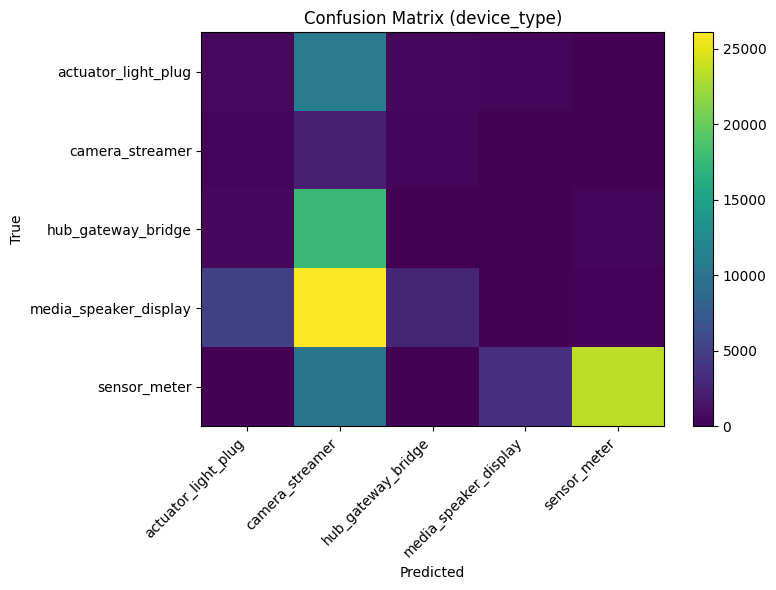

In [11]:
# 6b) Confusion matrix (types)
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8,6))
plt.imshow(cm, aspect='auto')
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.yticks(range(len(labels)), labels)
plt.title("Confusion Matrix (device_type)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()
